# EDA — Thesis §5.1  
Figures for sections 5.1.1 – 5.1.6. Run from `tvae/` root.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')

# Anchor to project root regardless of kernel launch directory
for _root in ['/mnt/workspace/tvae', os.path.expanduser('~/workspace/tvae')]:
    if os.path.isdir(_root):
        os.chdir(_root)
        break
print('Working dir:', os.getcwd())

DATA_DIR = 'data/processed/adults'
PARQUET  = 'data/interim/combined_filtered.parquet'
FIG_DIR  = 'results/eda'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Palette: bluish, minimal, serious ──────────────────────────────────────
C = dict(
    dark  = '#1a4f72',
    mid   = '#2980b9',
    light = '#85c1e9',
    pale  = '#d6eaf8',
    grey  = '#95a5a6',
    black = '#2c3e50',
    red   = '#c0392b',
)
MOD_PAL = {'AID': C['dark'], 'SAP': C['mid'], 'MDI': C['light']}
DS_PAL  = {'METABONET': C['dark'], 'T1DEXI': C['mid']}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.frameon':    False,
    'figure.dpi':        150,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
})

IDX_CGM, IDX_PI, IDX_RA  = 0, 1, 2
IDX_HSIN, IDX_HCOS        = 3, 4
IDX_BOLUS, IDX_CARBS      = 5, 6

print('Setup complete.')

Working dir: /mnt/workspace/tvae
Setup complete.


## Data loading — single pass over all .npz files

In [2]:
import zipfile

npz_files = sorted(glob.glob(f'{DATA_DIR}/*.npz'))
print(f'Found {len(npz_files)} patient files')

# Hourly accumulators
h_cgm_sum = np.zeros(24); h_cgm_sq = np.zeros(24)
h_pi_sum  = np.zeros(24); h_pi_sq  = np.zeros(24)
h_ra_sum  = np.zeros(24); h_ra_sq  = np.zeros(24)
h_count   = np.zeros(24, dtype=np.int64)

# CGM population histogram accumulator
cgm_hist_edges  = np.linspace(40, 400, 401)
cgm_hist_counts = np.zeros(400, dtype=np.int64)

# Per-window driver-blindness accumulators
window_cgm_ranges   = []   # CGM range (max-min mg/dL) per 24h window
window_is_annotated = []   # True if window has ≥1 bolus OR carbs event

records          = []
window_null_frac = []
skipped          = 0

for fpath in npz_files:
    try:
        d        = np.load(fpath, allow_pickle=True)
        pid      = str(d['patient_id'][0])
        modality = str(d['modality'][0]).upper().strip()
        age      = float(d['age'][0])
        sm       = d['scaler_mean'].astype(float)
        ss       = d['scaler_std'].astype(float)
        W        = d['windows'].astype(np.float32)    # (N, 288, 11)
    except Exception:
        skipped += 1
        continue

    N   = W.shape[0]
    cgm = W[:, :, IDX_CGM] * ss[0] + sm[0]           # (N, 288) mg/dL

    null_w = np.isnan(W[:, :, IDX_CGM]).mean(axis=1)
    window_null_frac.extend(null_w.tolist())

    cgm_flat = cgm.ravel()
    valid    = cgm_flat[~np.isnan(cgm_flat)]
    mean_g   = float(np.mean(valid))  if valid.size else np.nan
    std_g    = float(np.std(valid))   if valid.size else np.nan
    cv       = std_g / mean_g * 100   if (mean_g and mean_g > 0) else np.nan
    tir      = float(np.mean((valid >= 70) & (valid <= 180))) * 100 if valid.size else np.nan
    hypo     = float(np.mean(valid < 70))  * 100 if valid.size else np.nan
    hyper    = float(np.mean(valid > 180)) * 100 if valid.size else np.nan
    pat_null = float(null_w.mean())

    # Accumulate population CGM histogram
    if valid.size:
        cgm_hist_counts += np.histogram(valid, bins=cgm_hist_edges)[0]

    has_bolus = float(np.mean(np.any(W[:, :, IDX_BOLUS] > 0.5, axis=1))) * 100
    has_carbs = float(np.mean(np.any(W[:, :, IDX_CARBS] > 0.5, axis=1))) * 100

    # Per-window CGM range and annotation status (driver blindness)
    cgm_range    = cgm.max(axis=1) - cgm.min(axis=1)
    is_annotated = ((W[:, :, IDX_BOLUS] > 0.5).any(axis=1) |
                    (W[:, :, IDX_CARBS] > 0.5).any(axis=1))
    window_cgm_ranges.extend(cgm_range.tolist())
    window_is_annotated.extend(is_annotated.tolist())

    hsin_r = W[:, :, IDX_HSIN].ravel()
    hcos_r = W[:, :, IDX_HCOS].ravel()
    pi_r   = W[:, :, IDX_PI].ravel()
    ra_r   = W[:, :, IDX_RA].ravel()
    cgm_r  = cgm.ravel()
    hrs    = (np.arctan2(hsin_r, hcos_r) / (2 * np.pi) * 24 % 24).astype(int).clip(0, 23)
    vmask  = ~np.isnan(cgm_r)
    hv     = hrs[vmask]
    h_count   += np.bincount(hv, minlength=24)
    h_cgm_sum += np.bincount(hv, weights=cgm_r[vmask],    minlength=24)
    h_cgm_sq  += np.bincount(hv, weights=cgm_r[vmask]**2, minlength=24)
    h_pi_sum  += np.bincount(hv, weights=pi_r[vmask],     minlength=24)
    h_pi_sq   += np.bincount(hv, weights=pi_r[vmask]**2,  minlength=24)
    h_ra_sum  += np.bincount(hv, weights=ra_r[vmask],     minlength=24)
    h_ra_sq   += np.bincount(hv, weights=ra_r[vmask]**2,  minlength=24)

    records.append(dict(
        patient_id  = pid,
        modality    = modality,
        age         = age,
        mean_glucose= mean_g,
        std_glucose = std_g,
        cv          = cv,
        tir         = tir,
        hypo        = hypo,
        hyper       = hyper,
        null_frac   = pat_null * 100,
        has_bolus   = has_bolus,
        has_carbs   = has_carbs,
        n_windows   = N,
    ))
    del W, cgm

# Build patient_id → file path lookup (used by §5.1.4)
pid_to_path = {os.path.splitext(os.path.basename(f))[0]: f for f in npz_files}

pts = pd.DataFrame(records)
window_null_frac    = np.array(window_null_frac) * 100
window_cgm_ranges   = np.array(window_cgm_ranges,   dtype=np.float32)
window_is_annotated = np.array(window_is_annotated, dtype=bool)

safe_n     = np.maximum(h_count, 1)
h_cgm_mean = h_cgm_sum / safe_n
h_cgm_std  = np.sqrt(np.maximum(h_cgm_sq / safe_n - h_cgm_mean**2, 0))
h_pi_mean  = h_pi_sum  / safe_n
h_pi_std   = np.sqrt(np.maximum(h_pi_sq  / safe_n - h_pi_mean**2,  0))
h_ra_mean  = h_ra_sum  / safe_n
h_ra_std   = np.sqrt(np.maximum(h_ra_sq  / safe_n - h_ra_mean**2,  0))
hours_x    = np.arange(24)

print(f'Patients loaded: {len(pts)}  (skipped {skipped} corrupt files)')
print(pts['modality'].value_counts().to_string())
print(f'Total windows: {len(window_null_frac):,}')
print(f'Unannotated windows: {(~window_is_annotated).mean()*100:.1f}%')

Found 1037 patient files


Patients loaded: 1035  (skipped 2 corrupt files)
AID        837
SAP        106
MDI         88
UNKNOWN      4
Total windows: 1,096,444
Unannotated windows: 10.3%


## Load dataset source from parquet (memory-safe batch read)

In [3]:
# Read id + source_file + gender in batches to avoid OOM on 1.3 GB parquet
pf = pq.ParquetFile(PARQUET)
src_chunks = []
for batch in pf.iter_batches(batch_size=2_000_000, columns=['id', 'source_file', 'gender']):
    chunk = batch.to_pandas()
    chunk['patient_id'] = chunk['id'].astype(str)
    src_chunks.append(chunk[['patient_id', 'source_file', 'gender']].drop_duplicates('patient_id'))
    del chunk

src_df = (pd.concat(src_chunks, ignore_index=True)
            .drop_duplicates('patient_id')
            .assign(dataset=lambda d: d.source_file
                    .str.contains('METABONET').map({True: 'METABONET', False: 'T1DEXI'})))
del src_chunks

pts = pts.merge(src_df[['patient_id', 'dataset', 'gender']], on='patient_id', how='left')
pts['dataset'] = pts['dataset'].fillna('Unknown')
pts['gender']  = pts['gender'].fillna('Unknown').str.capitalize()

print(pts.dataset.value_counts().to_string())
print('\nGender breakdown:')
print(pts.gender.value_counts().to_string())
print('Merge coverage:', pts['dataset'].ne('Unknown').mean())

METABONET    547
T1DEXI       488

Gender breakdown:
Female        649
Male          341
Unknown        44
Non-binary      1
Merge coverage: 1.0


## §5.1.1 Cohort Demographics

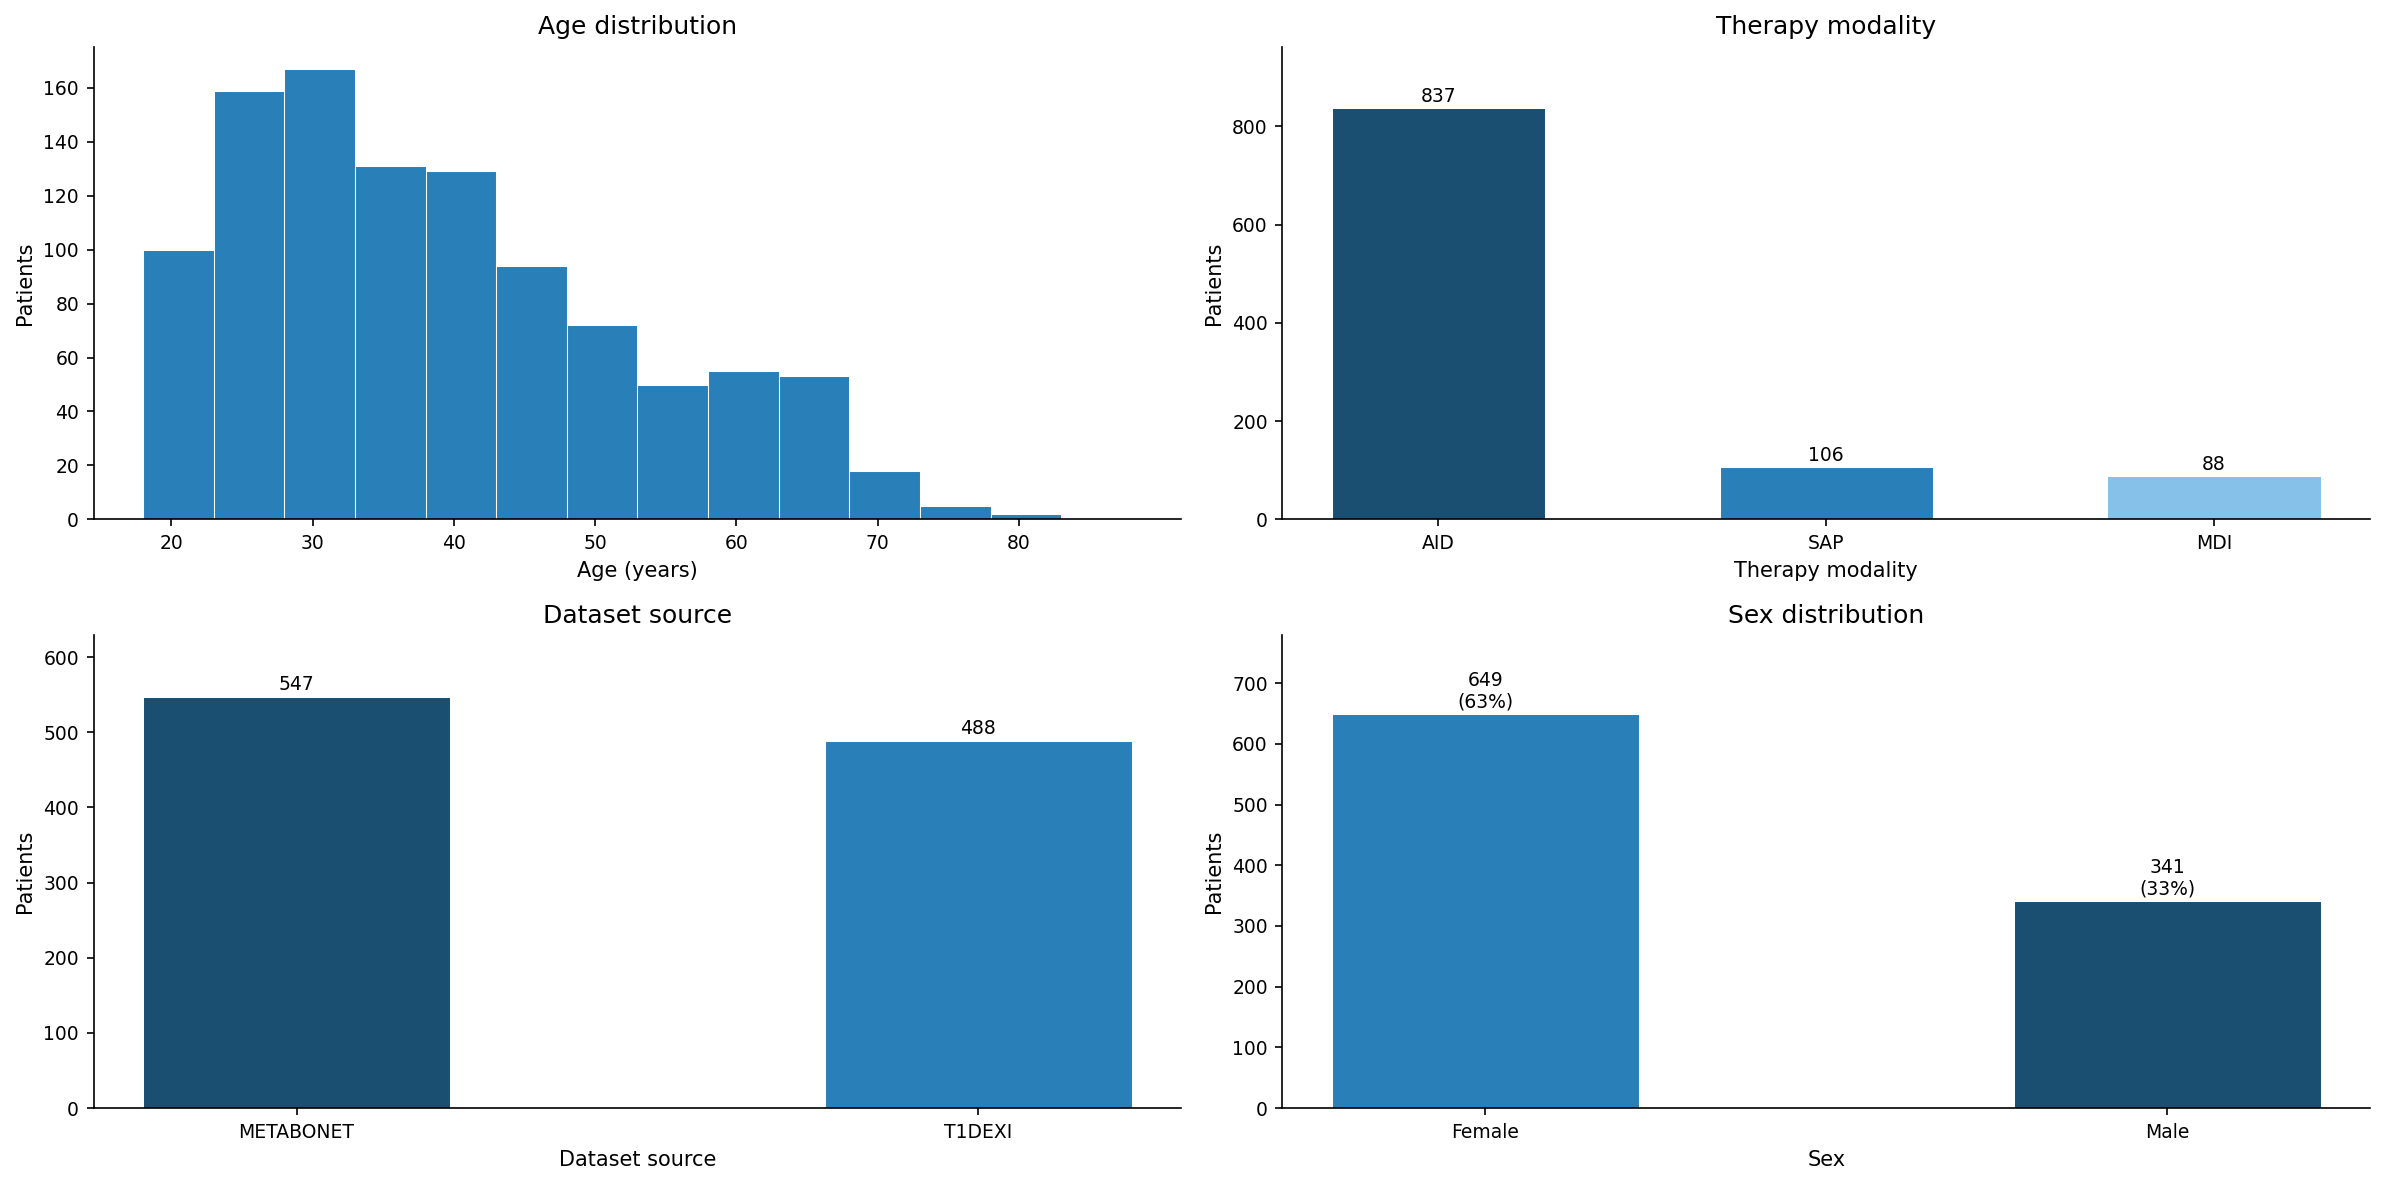

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()

# ── Panel 1: Age distribution ───────────────────────────────────────────────
ax = axes[0]
bins = np.arange(18, 90, 5)
ax.hist(pts['age'].dropna(), bins=bins, color=C['mid'],
        edgecolor='white', linewidth=0.5)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Patients')
ax.set_title('Age distribution')
ax.set_xticks(range(20, 90, 10))

# ── Panel 2: Therapy modality ───────────────────────────────────────────────
ax = axes[1]
mod_counts = pts['modality'].value_counts().reindex(['AID', 'SAP', 'MDI'], fill_value=0)
bars = ax.bar(mod_counts.index,
              mod_counts.values,
              color=[MOD_PAL[m] for m in mod_counts.index],
              edgecolor='white', linewidth=0.5, width=0.55)
for bar, val in zip(bars, mod_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4, str(val),
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Therapy modality')
ax.set_ylabel('Patients')
ax.set_title('Therapy modality')
ax.set_ylim(0, mod_counts.max() * 1.15)

# ── Panel 3: Dataset source ─────────────────────────────────────────────────
ax = axes[2]
ds_counts = pts['dataset'].value_counts().reindex(['METABONET', 'T1DEXI'], fill_value=0)
bars = ax.bar(ds_counts.index,
              ds_counts.values,
              color=[DS_PAL[d] for d in ds_counts.index],
              edgecolor='white', linewidth=0.5, width=0.45)
for bar, val in zip(bars, ds_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4, str(val),
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Dataset source')
ax.set_ylabel('Patients')
ax.set_title('Dataset source')
ax.set_ylim(0, ds_counts.max() * 1.15)

# ── Panel 4: Sex ────────────────────────────────────────────────────────────
ax = axes[3]
sex_order  = ['Female', 'Male']
sex_counts = pts['gender'].value_counts().reindex(sex_order, fill_value=0)
sex_colors = [C['mid'], C['dark']]
bars = ax.bar(sex_counts.index,
              sex_counts.values,
              color=sex_colors,
              edgecolor='white', linewidth=0.5, width=0.45)
for bar, val in zip(bars, sex_counts.values):
    pct = val / len(pts) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4, f'{val}\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Sex')
ax.set_ylabel('Patients')
ax.set_title('Sex distribution')
ax.set_ylim(0, sex_counts.max() * 1.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_1_demographics.png')
plt.show()

## §5.1.2 CGM Signal Quality

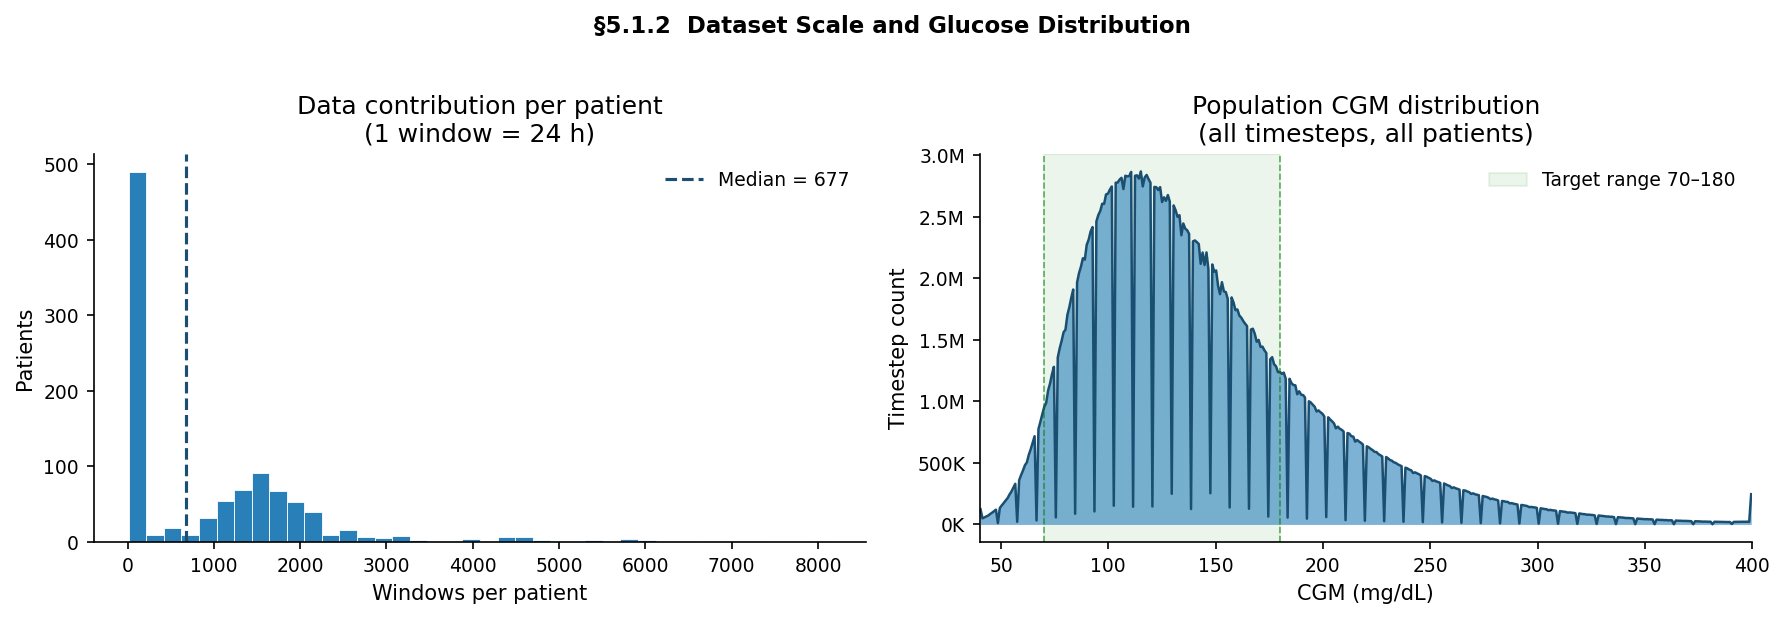

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Panel 1: Windows per patient distribution ───────────────────────────────
ax = axes[0]
ax.hist(pts['n_windows'], bins=40, color=C['mid'],
        edgecolor='white', linewidth=0.4)
med_w = pts['n_windows'].median()
ax.axvline(med_w, color=C['dark'], linewidth=1.5, linestyle='--',
           label=f'Median = {med_w:.0f}')
ax.set_xlabel('Windows per patient')
ax.set_ylabel('Patients')
ax.set_title('Data contribution per patient\n(1 window = 24 h)')
ax.legend()

# ── Panel 2: Population CGM distribution ───────────────────────────────────
ax = axes[1]
bin_centres = (cgm_hist_edges[:-1] + cgm_hist_edges[1:]) / 2
ax.fill_between(bin_centres, cgm_hist_counts, alpha=0.6,
                color=C['mid'], linewidth=0)
ax.plot(bin_centres, cgm_hist_counts, color=C['dark'], linewidth=1.2)
ax.axvspan(70, 180, color='green', alpha=0.08, zorder=0, label='Target range 70–180')
ax.axvline(70,  color='green', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(180, color='green', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('CGM (mg/dL)')
ax.set_ylabel('Timestep count')
ax.set_title('Population CGM distribution\n(all timesteps, all patients)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.legend()
ax.set_xlim(40, 400)

plt.suptitle('§5.1.2  Dataset Scale and Glucose Distribution',
             fontsize=11, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_2_data_distribution.png')
plt.show()

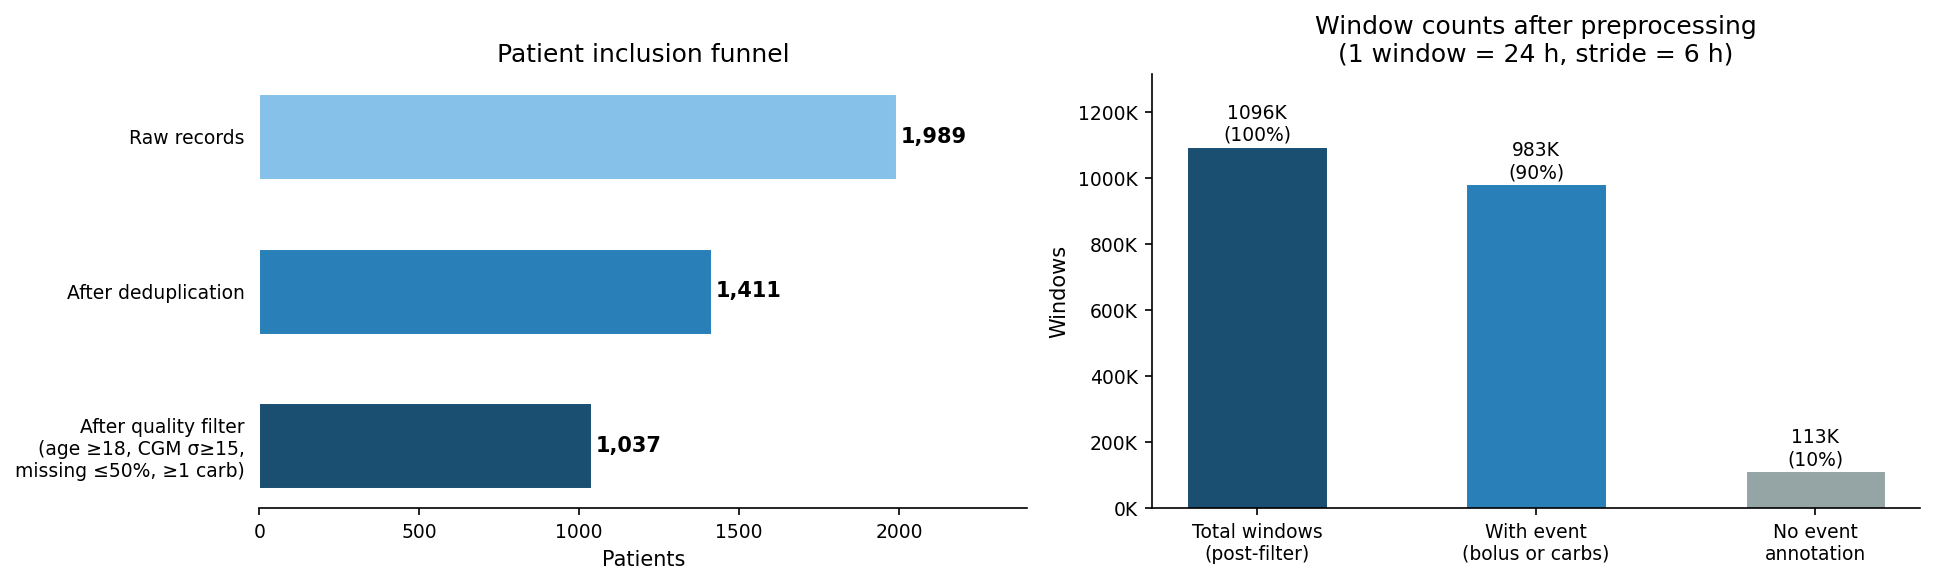

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel 1: Patient inclusion funnel ───────────────────────────────────────
ax = axes[0]
stages  = ['Raw records', 'After deduplication', 'After quality filter\n(age ≥18, CGM σ≥15,\nmissing ≤50%, ≥1 carb)']
counts  = [1989, 1411, 1037]
colors  = [C['light'], C['mid'], C['dark']]
y_pos   = [2, 1, 0]

bars = ax.barh(y_pos, counts, color=colors, edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars, counts):
    ax.text(val + 15, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10, fontweight='semibold')
ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=9)
ax.set_xlabel('Patients')
ax.set_xlim(0, 2400)
ax.set_title('Patient inclusion funnel')
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

# ── Panel 2: Total windows breakdown ────────────────────────────────────────
ax = axes[1]
total_w    = len(window_null_frac)
ann_w      = int(window_is_annotated.sum())
unann_w    = total_w - ann_w

labels = ['Total windows\n(post-filter)', 'With event\n(bolus or carbs)', 'No event\nannotation']
values = [total_w, ann_w, unann_w]
colors2 = [C['dark'], C['mid'], C['grey']]

bars = ax.bar(labels, values, color=colors2, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, values):
    pct = val / total_w * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5000,
            f'{val/1e3:.0f}K\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Windows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_title('Window counts after preprocessing\n(1 window = 24 h, stride = 6 h)')
ax.set_ylim(0, total_w * 1.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_2b_dataset_scale.png')
plt.show()

## §5.1.3 Driver-Blindness: Event Annotation Rates

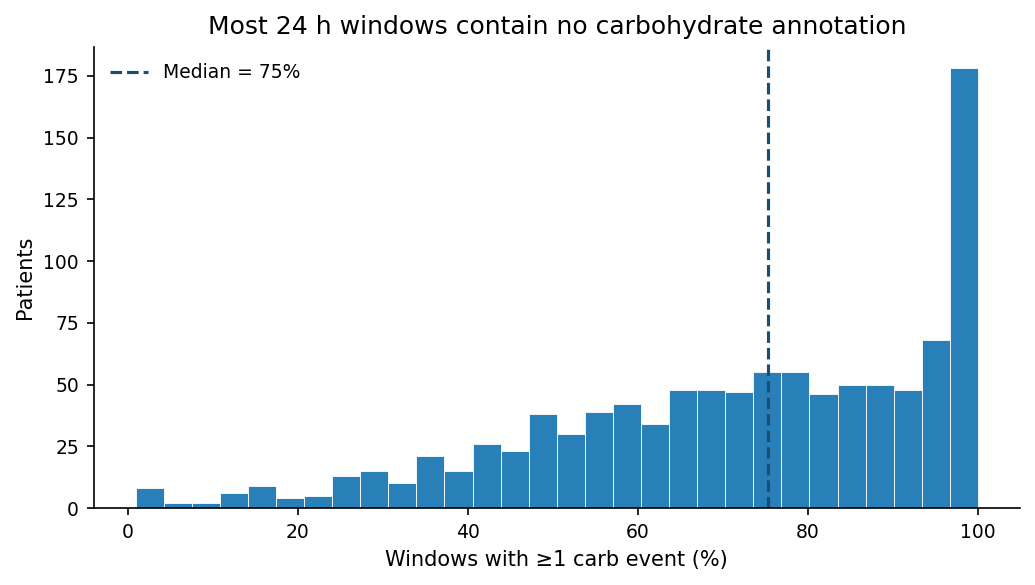

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(pts['has_carbs'], bins=30, color=C['mid'], edgecolor='white', linewidth=0.4)

med = pts['has_carbs'].median()
ax.axvline(med, color=C['dark'], linewidth=1.5, linestyle='--',
           label=f'Median = {med:.0f}%')

ax.set_xlabel('Windows with ≥1 carb event (%)')
ax.set_ylabel('Patients')
ax.set_title('Most 24 h windows contain no carbohydrate annotation')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_3_driver_blindness.png')
plt.show()

## §5.1.X — Mean Glucose Distribution by Modality

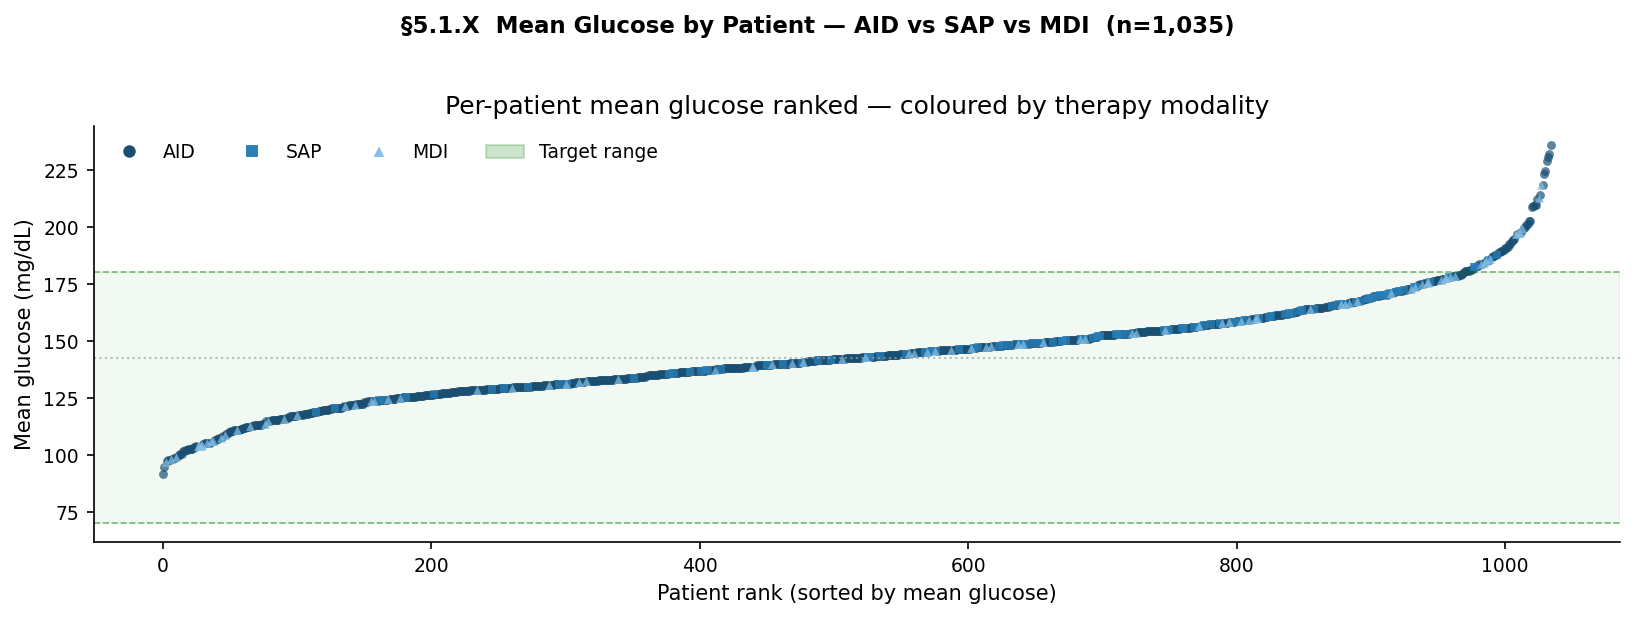

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))

mods_ordered = ['AID', 'SAP', 'MDI']
markers = {'AID': 'o', 'SAP': 's', 'MDI': '^'}

# Plot each modality sorted by mean glucose
all_sorted = pts.dropna(subset=['mean_glucose']).sort_values('mean_glucose').reset_index(drop=True)
all_sorted['rank'] = np.arange(len(all_sorted))

for mod in mods_ordered:
    sub = all_sorted[all_sorted['modality'] == mod]
    ax.scatter(sub['rank'], sub['mean_glucose'],
               color=MOD_PAL[mod], marker=markers[mod],
               s=18, alpha=0.7, linewidths=0, label=mod)

# Clinical reference lines
ax.axhline(70,  color='green', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(180, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhspan(70, 180, color='green', alpha=0.05, zorder=0, label='Target range')
ax.axhline(all_sorted['mean_glucose'].median(), color=C['grey'],
           linewidth=1.0, linestyle=':', alpha=0.7,
           label=f'Cohort median ({all_sorted["mean_glucose"].median():.0f} mg/dL)')

ax.set_xlabel('Patient rank (sorted by mean glucose)')
ax.set_ylabel('Mean glucose (mg/dL)')
ax.set_title('Per-patient mean glucose ranked — coloured by therapy modality')

handles = [
    Line2D([0], [0], marker=markers[m], color='w',
           markerfacecolor=MOD_PAL[m], markersize=7, label=m)
    for m in mods_ordered
] + [
    plt.Rectangle((0, 0), 1, 1, color='green', alpha=0.2, label='Target range'),
]
ax.legend(handles=handles, loc='upper left', ncol=4)

plt.suptitle(f'§5.1.X  Mean Glucose by Patient — AID vs SAP vs MDI  (n={len(all_sorted):,})',
             fontsize=11, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_x_mean_glucose_modality.png')
plt.show()

## §5.1.4 Physiological Pattern Validation

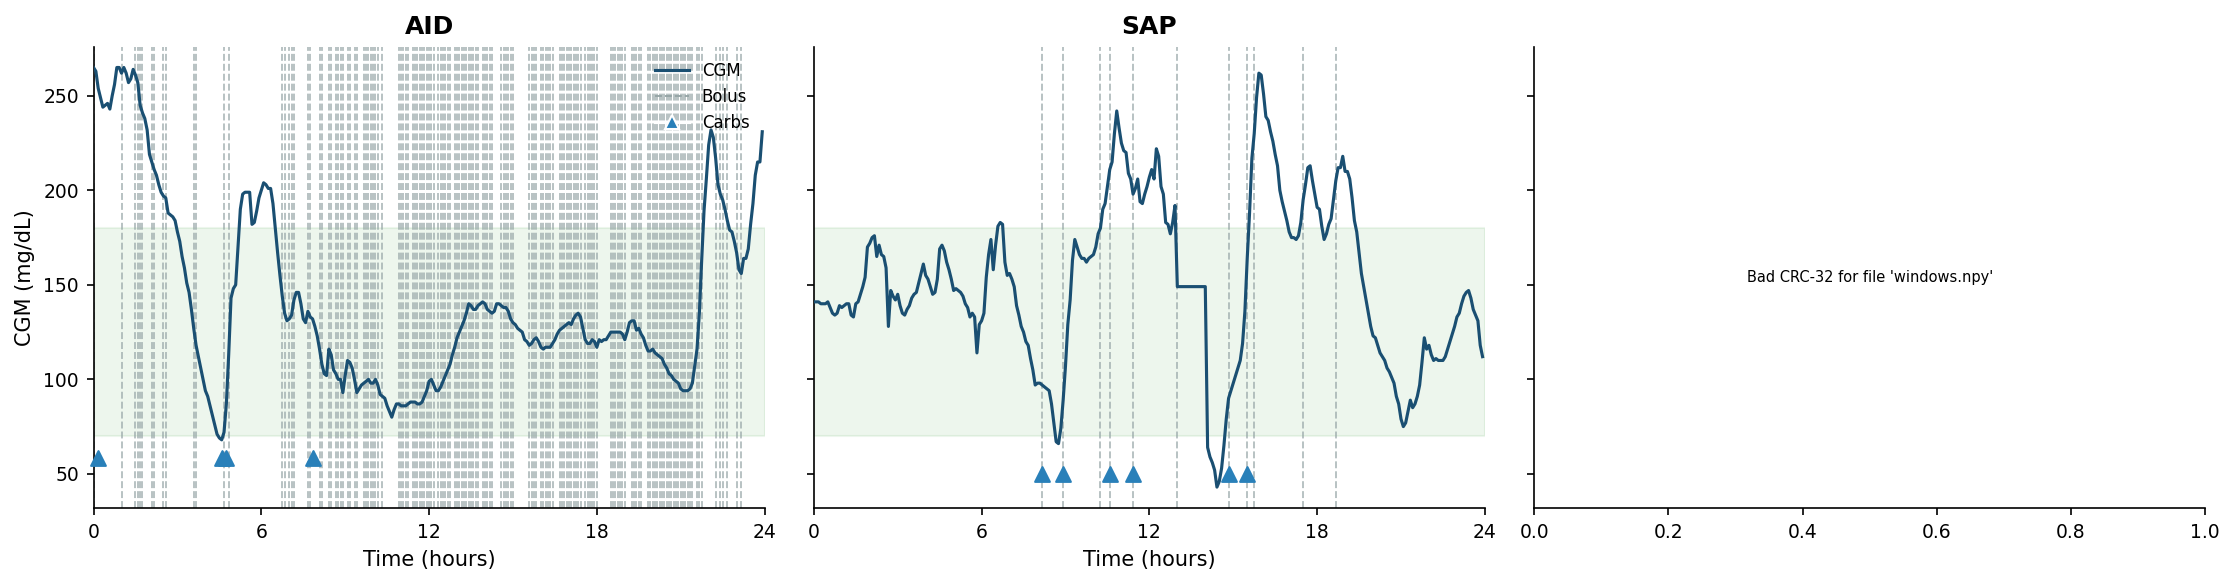

In [9]:
def _load_representative_window(pid, scaler_mean, scaler_std, npz_path):
    """Load one window with a bolus event from a patient's npz file."""
    d   = np.load(npz_path, allow_pickle=True)
    W   = d['windows'].astype(np.float32)           # (N, 288, 11)
    sm  = d['scaler_mean'].astype(float)
    ss  = d['scaler_std'].astype(float)
    cgm = W[:, :, IDX_CGM] * ss[0] + sm[0]         # mg/dL

    has_both   = np.any(W[:, :, IDX_BOLUS] > 0.5, axis=1) & np.any(W[:, :, IDX_CARBS] > 0.5, axis=1)
    has_bolus  = np.any(W[:, :, IDX_BOLUS] > 0.5, axis=1)
    candidates = np.where(has_both)[0] if has_both.any() else np.where(has_bolus)[0]
    if len(candidates) == 0:
        candidates = np.arange(len(W))
    idx = candidates[len(candidates) // 2]
    return cgm[idx], W[idx, :, IDX_BOLUS], W[idx, :, IDX_CARBS]

mods_ordered = ['AID', 'SAP', 'MDI']

rep_patients = {}
for mod in mods_ordered:
    sub = pts[(pts['modality'] == mod) & pts['tir'].notna()]
    if sub.empty:
        continue
    median_tir = sub['tir'].median()
    rep = sub.iloc[(sub['tir'] - median_tir).abs().argsort().iloc[0]]
    rep_patients[mod] = rep

time_h = np.arange(288) * 5 / 60

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mod in zip(axes, mods_ordered):
    if mod not in rep_patients:
        ax.set_visible(False)
        continue

    row  = rep_patients[mod]
    pid  = row['patient_id']
    path = pid_to_path.get(pid)
    if path is None:
        ax.text(0.5, 0.5, 'No file', ha='center', va='center', transform=ax.transAxes)
        continue

    try:
        cgm_trace, bolus_flag, carbs_flag = _load_representative_window(
            pid, row['mean_glucose'], row['std_glucose'], path)
    except Exception as e:
        ax.text(0.5, 0.5, str(e)[:40], ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
        continue

    ax.axhspan(70, 180, color='green', alpha=0.07, zorder=0)
    ax.plot(time_h, cgm_trace, color=C['dark'], linewidth=1.5, zorder=3)

    bolus_times = time_h[bolus_flag > 0.5]
    for t in bolus_times:
        ax.axvline(t, color=C['grey'], linewidth=0.9, linestyle='--', alpha=0.7, zorder=2)

    carbs_times = time_h[carbs_flag > 0.5]
    if carbs_times.size:
        ax.scatter(carbs_times,
                   np.full(carbs_times.size, ax.get_ylim()[0] if ax.get_ylim()[0] > 40 else 50),
                   marker='^', color=C['mid'], s=50, zorder=4, clip_on=False)

    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 6))
    ax.set_xlabel('Time (hours)')
    ax.set_title(mod, fontweight='semibold')

    if ax is axes[0]:
        ax.set_ylabel('CGM (mg/dL)')

    if ax is axes[0]:
        from matplotlib.lines import Line2D as _L
        ax.legend(handles=[
            _L([0], [0], color=C['dark'],  linewidth=1.5, label='CGM'),
            _L([0], [0], color=C['grey'],  linewidth=0.9, linestyle='--', label='Bolus'),
            _L([0], [0], marker='^', color='w', markerfacecolor=C['mid'],
               markersize=7, label='Carbs'),
        ], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_4_representative_traces.png')
plt.show()

## §5.1.5 Patient Heterogeneity and Phenotyping

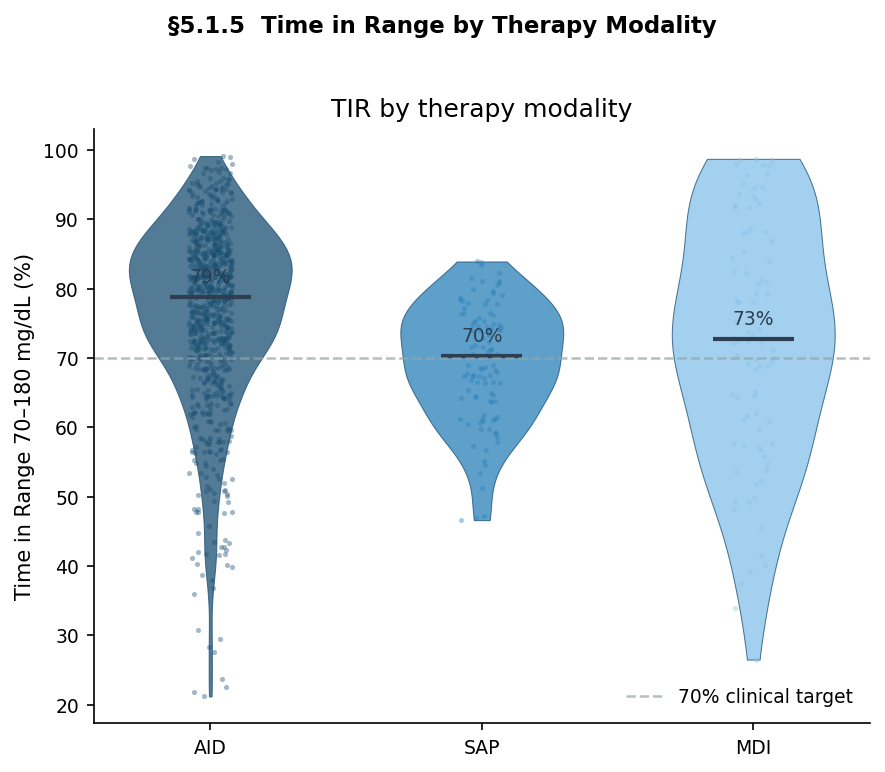

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

mods_ordered = ['AID', 'SAP', 'MDI']
tir_groups   = [pts[pts['modality'] == m]['tir'].dropna().values for m in mods_ordered]
positions    = [0, 1, 2]

vp = ax.violinplot(tir_groups, positions=positions, widths=0.6,
                    showmedians=True, showextrema=False)
for pc, mod in zip(vp['bodies'], mods_ordered):
    pc.set_facecolor(MOD_PAL[mod])
    pc.set_edgecolor(C['dark'])
    pc.set_linewidth(0.5)
    pc.set_alpha(0.75)
vp['cmedians'].set_color(C['black'])
vp['cmedians'].set_linewidth(2)

# Per-patient jittered dots
rng = np.random.default_rng(0)
for i, (mod, grp) in enumerate(zip(mods_ordered, tir_groups)):
    jitter = rng.uniform(-0.08, 0.08, size=len(grp))
    ax.scatter(i + jitter, grp, color=MOD_PAL[mod],
               s=6, alpha=0.4, linewidths=0)

# Median annotations
for i, grp in enumerate(tir_groups):
    med = np.median(grp)
    ax.text(i, med + 1.5, f'{med:.0f}%',
            ha='center', va='bottom', fontsize=9, color=C['black'])

# Clinical 70% target
ax.axhline(70, color=C['grey'], linewidth=1.2, linestyle='--', alpha=0.7,
           label='70% clinical target')

ax.set_xticks(positions)
ax.set_xticklabels(mods_ordered)
ax.set_ylabel('Time in Range 70–180 mg/dL (%)')
ax.set_title('TIR by therapy modality')
ax.legend(loc='lower right')

plt.suptitle('§5.1.5  Time in Range by Therapy Modality',
             fontsize=11, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_5_tir_modality.png')
plt.show()

## §5.1.6 Dataset Heterogeneity (METABONET vs T1DEXI)

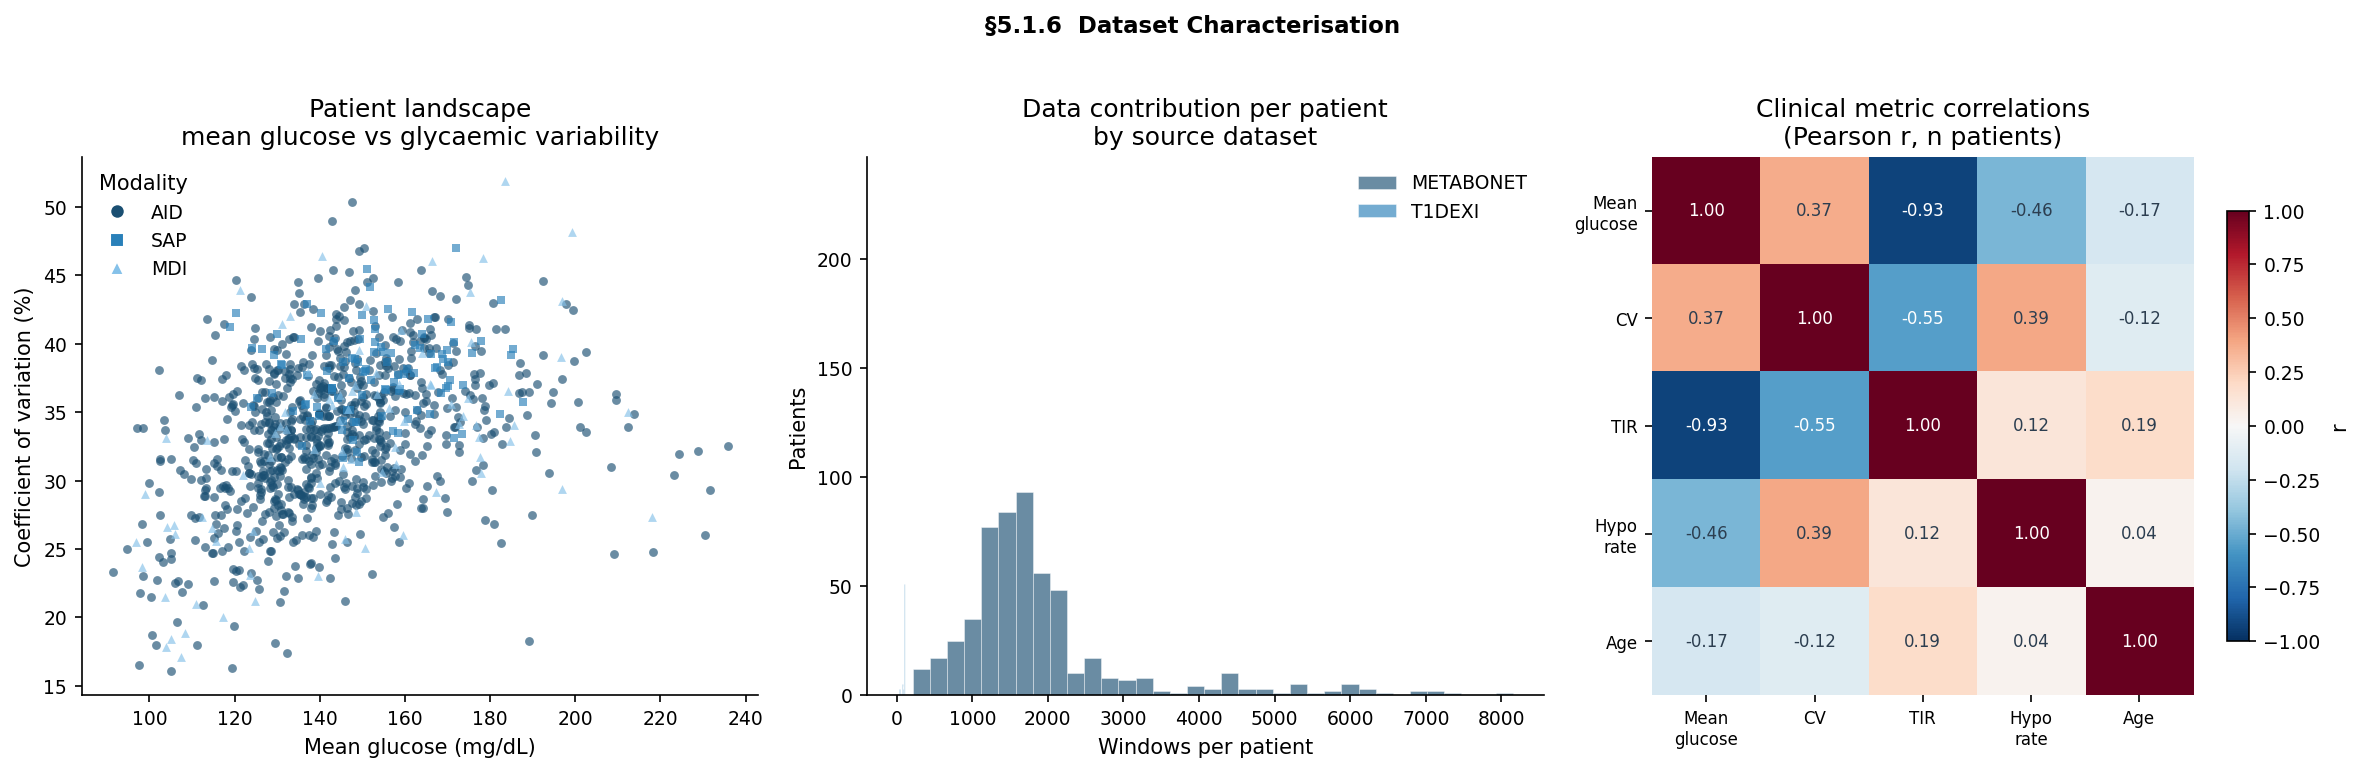

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Patient landscape — mean glucose vs CV, coloured by modality ───
ax = axes[0]
mods_ordered = ['AID', 'SAP', 'MDI']
markers = {'AID': 'o', 'SAP': 's', 'MDI': '^'}
for mod in mods_ordered:
    sub = pts[pts['modality'] == mod].dropna(subset=['mean_glucose', 'cv'])
    ax.scatter(sub['mean_glucose'], sub['cv'],
               color=MOD_PAL[mod], marker=markers[mod],
               s=18, alpha=0.65, linewidths=0, label=mod)
ax.set_xlabel('Mean glucose (mg/dL)')
ax.set_ylabel('Coefficient of variation (%)')
ax.set_title('Patient landscape\nmean glucose vs glycaemic variability')
handles = [Line2D([0], [0], marker=markers[m], color='w',
                  markerfacecolor=MOD_PAL[m], markersize=7, label=m)
           for m in mods_ordered]
ax.legend(handles=handles, title='Modality', loc='upper left')

# ── Panel 2: Windows per patient by dataset ─────────────────────────────────
ax = axes[1]
for ds in ['METABONET', 'T1DEXI']:
    sub = pts[pts['dataset'] == ds]['n_windows'].dropna()
    ax.hist(sub, bins=35, alpha=0.65, color=DS_PAL[ds],
            edgecolor='white', linewidth=0.3, label=ds)
ax.set_xlabel('Windows per patient')
ax.set_ylabel('Patients')
ax.set_title('Data contribution per patient\nby source dataset')
ax.legend()

# ── Panel 3: Glycaemic metric correlation heatmap ───────────────────────────
ax = axes[2]
corr_cols  = ['mean_glucose', 'cv', 'tir', 'hypo', 'age']
corr_labels= ['Mean\nglucose', 'CV', 'TIR', 'Hypo\nrate', 'Age']
corr_mat   = pts[corr_cols].corr().values

im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, fontsize=8)
ax.set_yticklabels(corr_labels, fontsize=8)
ax.set_title('Clinical metric correlations\n(Pearson r, n patients)')

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        val = corr_mat[i, j]
        color = 'white' if abs(val) > 0.5 else C['black']
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='r')
ax.spines[:].set_visible(False)

plt.suptitle('§5.1.6  Dataset Characterisation',
             fontsize=11, y=1.02, fontweight='semibold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/5_1_6_dataset_characterisation.png')
plt.show()

## Summary table
Print a summary for the thesis text.

## CGM trace illustration — TIR zones

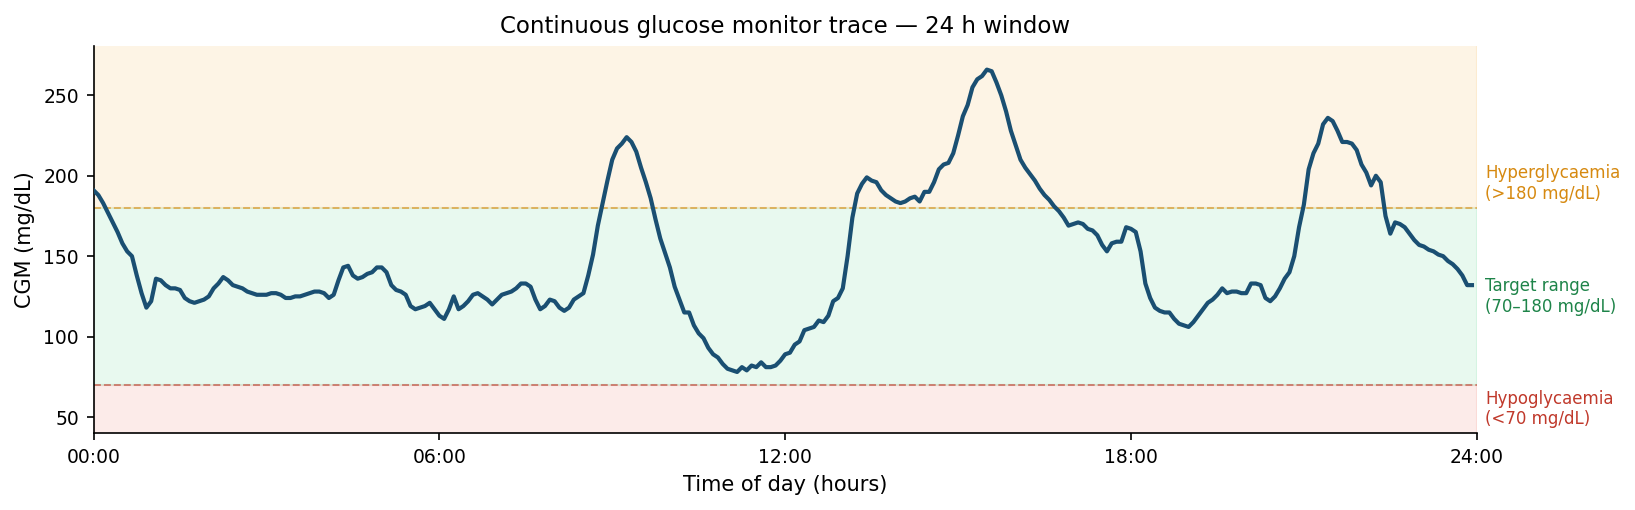

Trace: min=78  max=266  TIR=75%


In [12]:
# Find a real patient window: no NaN, peak > 210, trough < 160, not chaotic
selected_trace = None

candidates = pts[(pts['tir'] > 60) & (pts['tir'] < 82)].sample(
    frac=1, random_state=44).reset_index(drop=True)

for _, row in candidates.iterrows():
    path = pid_to_path.get(row['patient_id'])
    if path is None:
        continue
    try:
        d  = np.load(path, allow_pickle=True)
        sm = float(d['scaler_mean'][0])
        ss = float(d['scaler_std'][0])
        cgm_all = d['windows'].astype(np.float32)[:, :, IDX_CGM] * ss + sm
    except Exception:
        continue
    for i in range(len(cgm_all)):
        trace = cgm_all[i]
        if (np.isnan(trace).sum() == 0
                and trace.max() > 210
                and trace.min() < 165
                and trace.max() < 330
                and (trace > 180).mean() < 0.55
                and (trace < 70).mean() < 0.05):
            selected_trace = trace.copy()
            break
    if selected_trace is not None:
        break

assert selected_trace is not None, 'No suitable trace found'

time_h = np.arange(288) * 5 / 60

fig, ax = plt.subplots(figsize=(11, 3.5))

ax.axhspan(0,   70,  color='#f1948a', alpha=0.18, zorder=0)
ax.axhspan(70,  180, color='#82e0aa', alpha=0.18, zorder=0)
ax.axhspan(180, 400, color='#f8c471', alpha=0.18, zorder=0)

ax.axhline(70,  color='#c0392b', linewidth=0.9, linestyle='--', alpha=0.6)
ax.axhline(180, color='#d68910', linewidth=0.9, linestyle='--', alpha=0.6)

ax.plot(time_h, selected_trace, color=C['dark'], linewidth=2.0, zorder=3)

y_max = max(selected_trace.max() + 15, 230)
ax.text(24.15, 55,  'Hypoglycaemia\n(<70 mg/dL)',   fontsize=8, va='center', color='#c0392b', clip_on=False)
ax.text(24.15, 125, 'Target range\n(70–180 mg/dL)', fontsize=8, va='center', color='#1e8449', clip_on=False)
ax.text(24.15, 195, 'Hyperglycaemia\n(>180 mg/dL)', fontsize=8, va='center', color='#d68910', clip_on=False)

ax.set_xlim(0, 24)
ax.set_ylim(40, y_max)
ax.set_xticks(range(0, 25, 6))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 6)])
ax.set_xlabel('Time of day (hours)')
ax.set_ylabel('CGM (mg/dL)')
ax.set_title('Continuous glucose monitor trace — 24 h window', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cgm_tir_illustration.png', bbox_inches='tight')
plt.show()
print(f'Trace: min={selected_trace.min():.0f}  max={selected_trace.max():.0f}  '
      f'TIR={((selected_trace>=70)&(selected_trace<=180)).mean()*100:.0f}%')

In [13]:
print('=== Cohort summary ===')
print(f'Total patients : {len(pts)}')
print(f'Age            : {pts["age"].mean():.1f} ± {pts["age"].std():.1f} yr  '
      f'(range {pts["age"].min():.0f}–{pts["age"].max():.0f})')
print()
print('Sex breakdown:')
print(pts['gender'].value_counts().to_frame('n').assign(pct=lambda d: d.n/len(pts)*100).to_string())
print()
print('Modality breakdown:')
print(pts['modality'].value_counts().to_frame('n').assign(pct=lambda d: d.n/len(pts)*100).to_string())
print()
print('Dataset source:')
print(pts['dataset'].value_counts().to_frame('n').assign(pct=lambda d: d.n/len(pts)*100).to_string())
print()
print('Glycaemic stats (mean ± SD across patients):')
for col, label in [('mean_glucose','Mean glucose (mg/dL)'),
                    ('cv',          'CV (%)'),
                    ('tir',         'TIR (%)'),
                    ('hypo',        'Hypo rate (%)')]:
    print(f'  {label:<28}: {pts[col].mean():.1f} ± {pts[col].std():.1f}')
print()
print(f'Total windows  : {len(window_null_frac):,}')
print(f'Windows > 20% null CGM: {(window_null_frac > 20).mean()*100:.1f}%')

=== Cohort summary ===
Total patients : 1035
Age            : 38.5 ± 13.7 yr  (range 18–80)

Sex breakdown:
              n        pct
Female      649  62.705314
Male        341  32.946860
Unknown      44   4.251208
Non-binary    1   0.096618

Modality breakdown:
           n        pct
AID      837  80.869565
SAP      106  10.241546
MDI       88   8.502415
UNKNOWN    4   0.386473

Dataset source:
             n        pct
METABONET  547  52.850242
T1DEXI     488  47.149758

Glycaemic stats (mean ± SD across patients):
  Mean glucose (mg/dL)        : 144.3 ± 22.5
  CV (%)                      : 33.7 ± 5.5
  TIR (%)                     : 75.3 ± 13.3
  Hypo rate (%)               : 3.2 ± 2.8

Total windows  : 1,096,444
Windows > 20% null CGM: 0.0%
